In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [ ]:
np.random.seed(42)
time_steps = 500
t = np.arange(time_steps)
stock_prices = 50 + 0.1 * t + 10 * np.sin(0.1 * t) + np.random.normal(0, 2, time_steps)

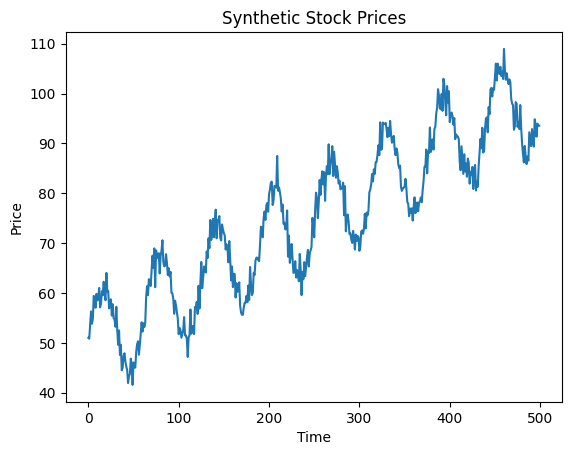

In [ ]:
plt.plot(t, stock_prices)
plt.title("Synthetic Stock Prices")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
stock_prices_scaled = scaler.fit_transform(stock_prices.reshape(-1, 1))

In [ ]:
def create_dataset(data, look_back=10):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:i+look_back])
        y.append(data[i+look_back])
    return np.array(X), np.array(y)

In [ ]:
look_back = 10
X, y = create_dataset(stock_prices_scaled, look_back)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (392, 10, 1)
y_train shape: (392, 1)


In [ ]:
model = Sequential([
LSTM(128, return_sequences=True, input_shape=(look_back, 1)),
LSTM(64),
Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train, y_train, epochs=100, batch_size=16, verbose=1)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0337
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0059
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0045
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0046
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0038
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0036
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0039
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0037
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0035
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0037
Epoch 11/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0030
Epoch 12/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0027
Epoch 13/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0026
Epoch 14/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0022
Epoch 15/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - lo

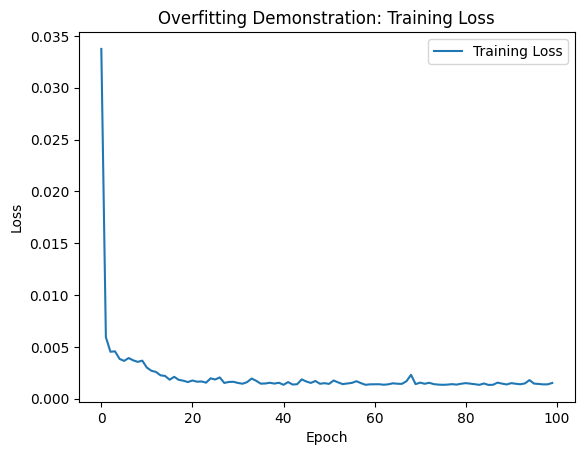

In [ ]:
plt.plot(history.history['loss'], label='Training Loss')
plt.title("Overfitting Demonstration: Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
test_loss = model.evaluate(X_test, y_test)
print(f"Test loss (expected to be high due to overfitting): {test_loss}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0015 
Test loss (expected to be high due to overfitting): 0.001467747031711042


In [ ]:
y_pred = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step


In [ ]:
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

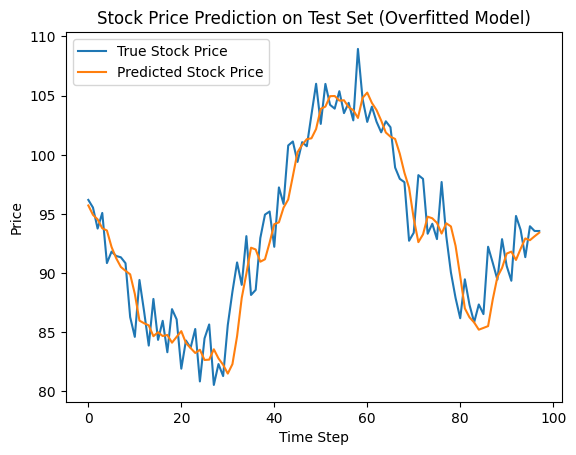

In [ ]:
plt.plot(y_test_inv, label='True Stock Price')
plt.plot(y_pred_inv, label='Predicted Stock Price')
plt.title("Stock Price Prediction on Test Set (Overfitted Model)")
plt.xlabel("Time Step")
plt.ylabel("Price")
plt.legend()
plt.show()